# Livrable Final - Modélisation, Implémentation et Exploitation

Ce notebook a été restructuré pour couvrir l'ensemble des attentes du livrable final :

- modélisation formelle du problème ;
- analyse de complexité ;
- génération d'instances aléatoires justifiée ;
- résolution par au moins deux méthodes différentes ;
- démonstration sur plusieurs cas de test ;
- étude expérimentale reproductible et interprétable.

Le problème retenu est un **CVRP** (*Capacitated Vehicle Routing Problem*) : plusieurs véhicules partent d'un dépôt, livrent un ensemble de clients et reviennent au dépôt, tout en respectant la capacité maximale des véhicules.

## 1. Cadrage du problème et contraintes retenues

Nous modélisons la livraison de marchandises sur un territoire à l'aide d'un graphe complet pondéré. Les deux contraintes métiers retenues sont :

- **l'utilisation de plusieurs véhicules** : la solution est composée de plusieurs sous-tournées au départ du même dépôt ;
- **la capacité maximale des véhicules** : chaque tournée doit rester compatible avec la charge utile disponible.

Ces choix sont cohérents avec l'énoncé ADEME : ils représentent une situation réaliste de logistique urbaine ou périurbaine, tout en restant suffisamment génériques pour permettre une étude algorithmique complète.

Dans ce notebook, nous comparerons deux familles de méthodes constructives :

1. une heuristique **Sweep + Plus Proche Voisin** ;
2. l'heuristique des **Savings de Clarke & Wright**.

Nous ajouterons également une amélioration locale **2-opt** pour montrer l'impact d'une phase d'optimisation après construction.

## 2. Modélisation formelle

On considère un graphe complet pondéré :

- $G = (V, E)$ avec $V = \{0\} \cup C$ ;
- le sommet $0$ représente le **dépôt** ;
- $C = \{1, 2, \dots, n\}$ représente l'ensemble des **clients** ;
- pour tout couple $(i, j)$ de sommets distincts, l'arête $(i, j)$ appartient à $E$ ;
- $c_{ij} \ge 0$ est le coût de déplacement de $i$ vers $j$.

Chaque client $i \in C$ possède une demande $q_i > 0$. Tous les véhicules sont supposés homogènes et de capacité maximale $Q$.

Une solution est un ensemble de tournées $R = \{r_1, r_2, \dots, r_m\}$ tel que chaque tournée :

- commence au dépôt ;
- visite un sous-ensemble de clients ;
- revient au dépôt.

On note une tournée sous la forme $r = (0, v_1, v_2, \dots, v_p, 0)$.

### Fonction objectif

Minimiser le coût total parcouru :

$$\min \sum_{r \in R} \sum_{h=0}^{|r|-2} c_{r_h, r_{h+1}}$$

### Contraintes

1. **Visite unique** : chaque client est visité une et une seule fois.

$$\forall i \in C,\quad \sum_{r \in R} \mathbf{1}_{\{i \in r\}} = 1$$

2. **Capacité** : la demande totale transportée sur une tournée ne dépasse pas $Q$.

$$\forall r \in R,\quad \sum_{i \in r \cap C} q_i \le Q$$

3. **Structure des tournées** : chaque tournée part du dépôt et y revient.

$$\forall r \in R,\quad r_0 = 0 \text{ et } r_{|r|-1} = 0$$

4. **Multi-véhicules** : le nombre de véhicules utilisés est $m = |R|$.

Dans notre implémentation, ce nombre n'est pas fixé a priori ; il est induit par les contraintes de capacité. Si l'on souhaite imposer une taille de flotte maximale $K_{\max}$, il suffit d'ajouter la contrainte $|R| \le K_{\max}$.

### Hypothèses de génération

- le graphe est **complet** ;
- les coûts sont des **distances euclidiennes** entre coordonnées 2D ;
- le dépôt est placé au centre de la zone ;
- les clients sont distribués soit uniformément, soit en grappes (*clustered*) afin de simuler différents types de territoires.

## 3. Analyse de complexité

Le problème traité est une variante du **Vehicle Routing Problem** avec capacité. Il généralise le **TSP** : si la capacité est suffisamment grande pour tout transporter avec un seul véhicule, on retrouve un problème de tournée unique.

Comme le TSP est NP-difficile, le CVRP est lui aussi **NP-difficile**. En pratique, cela signifie qu'une résolution exacte devient rapidement coûteuse quand le nombre de clients augmente.

### Complexité des méthodes utilisées

- **Génération d'instance** : le calcul de la matrice des distances coûte $O(n^2)$.
- **Sweep + Plus Proche Voisin** : tri angulaire en $O(n \log n)$ puis construction de routes. Avec l'évaluation de plusieurs rotations, on reste en pratique autour de $O(n^3)$.
- **Clarke & Wright Savings** : le calcul des savings est en $O(n^2)$ et leur tri en $O(n^2 \log n)$.
- **2-opt** : sur une tournée de taille $p$, la recherche locale est en pratique autour de $O(p^3)$ dans notre implémentation naïve.

### Conséquence pour le projet

Une résolution exacte n'est pas le meilleur choix pour un démonstrateur devant produire rapidement des solutions sur des tailles moyennes. Nous privilégions donc des **heuristiques** et **métaheuristiques légères**, capables de fournir de bonnes solutions dans des temps faibles.

## 4. Paramètres des instances et protocole expérimental

### Paramètres de génération retenus

- **Nombre de clients** : variable selon les scénarios pour observer le passage à l'échelle.
- **Coordonnées** : zone carrée de taille `100 x 100`.
- **Demandes** : entiers aléatoires dans un intervalle fixé, par défaut entre `1` et `10`.
- **Capacité** : calculée à partir de la demande totale et d'un paramètre de tension `capacity_tightness`.
- **Distribution spatiale** :
  - `uniform` : clients dispersés de manière homogène ;
  - `clustered` : clients regroupés en zones denses, ce qui simule davantage une ville structurée en quartiers.

### Métriques observées

- **coût total** de la solution ;
- **nombre de véhicules** utilisés ;
- **temps d'exécution** ;
- **écart relatif au meilleur solveur** sur la même instance.

L'objectif n'est pas seulement de savoir quel algorithme est le meilleur, mais de comprendre **dans quels contextes** il devient intéressant.

In [19]:
from dataclasses import dataclass
from statistics import mean, stdev
from typing import Dict, List, Optional, Sequence, Tuple
import math
import random
import time

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


@dataclass
class CVRPInstance:
    coords: List[Tuple[float, float]]
    demands: List[int]
    capacity: int
    distance_matrix: List[List[float]]
    distribution: str
    seed: Optional[int] = None

    @property
    def num_clients(self) -> int:
        return len(self.demands) - 1


def euclidean_distance(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return math.hypot(a[0] - b[0], a[1] - b[1])


def compute_distance_matrix(coords: Sequence[Tuple[float, float]]) -> List[List[float]]:
    n = len(coords)
    matrix = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            distance = euclidean_distance(coords[i], coords[j])
            matrix[i][j] = distance
            matrix[j][i] = distance
    return matrix


def generate_coordinates(
    rng: random.Random,
    num_clients: int,
    grid_size: int = 100,
    distribution: str = 'uniform',
) -> List[Tuple[float, float]]:
    depot = (grid_size / 2, grid_size / 2)
    coords = [depot]

    if distribution == 'uniform':
        for _ in range(num_clients):
            coords.append((rng.uniform(0, grid_size), rng.uniform(0, grid_size)))
        return coords

    if distribution == 'clustered':
        centers = [
            (rng.uniform(0.2 * grid_size, 0.8 * grid_size), rng.uniform(0.2 * grid_size, 0.8 * grid_size))
            for _ in range(3)
        ]
        sigma = grid_size / 10
        for _ in range(num_clients):
            cx, cy = rng.choice(centers)
            x = min(grid_size, max(0.0, rng.gauss(cx, sigma)))
            y = min(grid_size, max(0.0, rng.gauss(cy, sigma)))
            coords.append((x, y))
        return coords

    raise ValueError("distribution doit valoir 'uniform' ou 'clustered'")


def generate_cvrp_instance(
    num_clients: int = 20,
    grid_size: int = 100,
    demand_range: Tuple[int, int] = (1, 10),
    capacity_tightness: float = 1.15,
    distribution: str = 'uniform',
    seed: Optional[int] = None,
) -> CVRPInstance:
    rng = random.Random(seed)
    coords = generate_coordinates(rng, num_clients, grid_size, distribution)
    demands = [0] + [rng.randint(demand_range[0], demand_range[1]) for _ in range(num_clients)]
    total_demand = sum(demands)

    target_routes = max(2, math.ceil(num_clients / 6))
    base_capacity = math.ceil(total_demand / target_routes)
    capacity = max(max(demands), math.ceil(base_capacity * capacity_tightness))

    distance_matrix = compute_distance_matrix(coords)
    return CVRPInstance(
        coords=coords,
        demands=demands,
        capacity=capacity,
        distance_matrix=distance_matrix,
        distribution=distribution,
        seed=seed,
    )


def route_load(route: Sequence[int], demands: Sequence[int]) -> int:
    return sum(demands[node] for node in route if node != 0)


def route_cost(route: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> float:
    return sum(distance_matrix[route[i]][route[i + 1]] for i in range(len(route) - 1))


def solution_cost(routes: Sequence[Sequence[int]], distance_matrix: Sequence[Sequence[float]]) -> float:
    return sum(route_cost(route, distance_matrix) for route in routes)


def describe_instance(instance: CVRPInstance) -> str:
    return (
        f"{instance.num_clients} clients | distribution={instance.distribution} | "
        f"demande totale={sum(instance.demands)} | capacité={instance.capacity}"
    )


def validate_solution(instance: CVRPInstance, routes: Sequence[Sequence[int]]) -> Dict[str, object]:
    expected_clients = set(range(1, instance.num_clients + 1))
    seen_clients: List[int] = []
    messages: List[str] = []

    for route_index, route in enumerate(routes, start=1):
        if len(route) < 2 or route[0] != 0 or route[-1] != 0:
            messages.append(f'Tournée {route_index} invalide : elle doit partir du dépôt et y revenir.')
        load = route_load(route, instance.demands)
        if load > instance.capacity:
            messages.append(
                f'Tournée {route_index} invalide : charge {load} > capacité {instance.capacity}.'
            )
        seen_clients.extend(node for node in route[1:-1])

    seen_set = set(seen_clients)
    missing = sorted(expected_clients - seen_set)
    duplicates = len(seen_clients) != len(seen_set)
    extras = sorted(seen_set - expected_clients)

    if missing:
        messages.append(f'Clients non servis : {missing}')
    if duplicates:
        messages.append('Certains clients sont visités plusieurs fois.')
    if extras:
        messages.append(f'Clients inattendus dans la solution : {extras}')

    return {
        'valid': len(messages) == 0,
        'messages': messages,
    }


def plot_instance(instance: CVRPInstance, ax=None, title: str = 'Instance'):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    depot_x, depot_y = instance.coords[0]
    client_x = [x for x, _ in instance.coords[1:]]
    client_y = [y for _, y in instance.coords[1:]]

    ax.scatter(client_x, client_y, s=40, color='#2f6f9f', label='Clients')
    ax.scatter([depot_x], [depot_y], s=150, marker='s', color='#d1495b', label='Dépôt')

    if instance.num_clients <= 25:
        for client in range(1, instance.num_clients + 1):
            x, y = instance.coords[client]
            ax.text(x + 1, y + 1, str(client), fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(loc='best')


def plot_solution(instance: CVRPInstance, routes: Sequence[Sequence[int]], ax=None, title: str = 'Solution'):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    plot_instance(instance, ax=ax, title=title)
    colors = plt.cm.tab20.colors

    for route_index, route in enumerate(routes):
        color = colors[route_index % len(colors)]
        xs = [instance.coords[node][0] for node in route]
        ys = [instance.coords[node][1] for node in route]
        label = f'Vehicule {route_index + 1} (charge={route_load(route, instance.demands)})'
        ax.plot(xs, ys, color=color, linewidth=2, marker='o', alpha=0.9, label=label)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), fontsize=8, loc='best')


## 5. Méthode 1 - Sweep + Plus Proche Voisin

Cette première méthode est volontairement simple et rapide.

### Idée

1. On trie les clients selon leur angle autour du dépôt (**sweep**).
2. On découpe cette liste en groupes compatibles avec la capacité du véhicule.
3. À l'intérieur de chaque groupe, on construit l'ordre de visite par **plus proche voisin**.

Cette approche est cohérente avec un usage multi-véhicules : on forme d'abord des zones de service, puis on ordonne chaque tournée.

### Limites

- le choix des groupes dépend fortement de l'ordre angulaire ;
- le plus proche voisin est glouton et peut produire des croisements ou des retours inefficaces.

In [20]:
def angle_sorted_clients(instance: CVRPInstance) -> List[int]:
    depot_x, depot_y = instance.coords[0]
    clients = list(range(1, instance.num_clients + 1))
    return sorted(
        clients,
        key=lambda client: math.atan2(
            instance.coords[client][1] - depot_y,
            instance.coords[client][0] - depot_x,
        ),
    )


def split_by_capacity(sequence: Sequence[int], demands: Sequence[int], capacity: int) -> List[List[int]]:
    routes: List[List[int]] = []
    current_route: List[int] = []
    current_load = 0

    for client in sequence:
        demand = demands[client]
        if current_route and current_load + demand > capacity:
            routes.append(current_route)
            current_route = []
            current_load = 0

        current_route.append(client)
        current_load += demand

    if current_route:
        routes.append(current_route)

    return routes


def nearest_neighbor_route(clients: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> List[int]:
    unvisited = set(clients)
    route = [0]
    current = 0

    while unvisited:
        next_client = min(unvisited, key=lambda client: distance_matrix[current][client])
        route.append(next_client)
        unvisited.remove(next_client)
        current = next_client

    route.append(0)
    return route


def solve_sweep_nn(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    ordered_clients = angle_sorted_clients(instance)

    if not ordered_clients:
        return [[0, 0]], 0.0

    best_routes: Optional[List[List[int]]] = None
    best_cost = float('inf')

    for shift in range(len(ordered_clients)):
        rotated = ordered_clients[shift:] + ordered_clients[:shift]
        groups = split_by_capacity(rotated, instance.demands, instance.capacity)
        routes = [nearest_neighbor_route(group, instance.distance_matrix) for group in groups]
        total = solution_cost(routes, instance.distance_matrix)

        if total < best_cost:
            best_cost = total
            best_routes = routes

    if best_routes is None:
        raise RuntimeError('Impossible de construire une solution Sweep + NN.')

    return best_routes, best_cost


def two_opt_route(route: Sequence[int], distance_matrix: Sequence[Sequence[float]]) -> List[int]:
    best_route = list(route)
    improved = True

    while improved:
        improved = False
        best_delta = 0.0
        best_i = None
        best_j = None

        for i in range(1, len(best_route) - 2):
            for j in range(i + 1, len(best_route) - 1):
                if j - i == 1:
                    continue

                current_edges = (
                    distance_matrix[best_route[i - 1]][best_route[i]]
                    + distance_matrix[best_route[j]][best_route[j + 1]]
                )
                new_edges = (
                    distance_matrix[best_route[i - 1]][best_route[j]]
                    + distance_matrix[best_route[i]][best_route[j + 1]]
                )
                delta = new_edges - current_edges

                if delta < best_delta - 1e-12:
                    best_delta = delta
                    best_i = i
                    best_j = j

        if best_i is not None and best_j is not None:
            best_route[best_i:best_j + 1] = reversed(best_route[best_i:best_j + 1])
            improved = True

    return best_route


def improve_solution_2opt(routes: Sequence[Sequence[int]], instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    improved_routes = [two_opt_route(route, instance.distance_matrix) for route in routes]
    return improved_routes, solution_cost(improved_routes, instance.distance_matrix)


def solve_sweep_nn_2opt(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    routes, _ = solve_sweep_nn(instance)
    return improve_solution_2opt(routes, instance)


## 6. Méthode 2 - Clarke & Wright Savings

L'heuristique des savings démarre avec une solution triviale où chaque client est desservi par un véhicule dédié : `(0, i, 0)`.

Pour deux clients $i$ et $j$, le **gain** à les mettre dans une même tournée vaut :

$$s_{ij} = c_{0i} + c_{0j} - c_{ij}$$

Plus ce gain est élevé, plus il est intéressant d'essayer de fusionner les deux tournées, à condition de rester compatible avec la capacité.

### Intérêt de cette méthode

- elle exploite directement la structure du coût ;
- elle produit souvent de meilleures solutions que les heuristiques purement gloutonnes ;
- elle reste très rapide sur des tailles moyennes.

Nous testons également une version **Clarke & Wright + 2-opt** pour voir si une amélioration locale apporte un gain supplémentaire.

In [21]:
def merge_routes_if_possible(
    route_a: Sequence[int],
    route_b: Sequence[int],
    client_i: int,
    client_j: int,
) -> Optional[List[int]]:
    body_a = list(route_a[1:-1])
    body_b = list(route_b[1:-1])

    if not body_a or not body_b:
        return None

    if body_a[-1] == client_i and body_b[0] == client_j:
        return [0] + body_a + body_b + [0]

    if body_a[0] == client_i and body_b[-1] == client_j:
        return [0] + list(reversed(body_a)) + list(reversed(body_b)) + [0]

    if body_a[-1] == client_i and body_b[-1] == client_j:
        return [0] + body_a + list(reversed(body_b)) + [0]

    if body_a[0] == client_i and body_b[0] == client_j:
        return [0] + list(reversed(body_a)) + body_b + [0]

    return None


def solve_clarke_wright(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    n = instance.num_clients
    dist = instance.distance_matrix
    demands = instance.demands

    routes: Dict[int, List[int]] = {client: [0, client, 0] for client in range(1, n + 1)}
    route_loads: Dict[int, int] = {client: demands[client] for client in range(1, n + 1)}
    client_to_route: Dict[int, int] = {client: client for client in range(1, n + 1)}

    savings: List[Tuple[float, int, int]] = []
    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            saving = dist[0][i] + dist[0][j] - dist[i][j]
            savings.append((saving, i, j))

    savings.sort(reverse=True)

    for _, i, j in savings:
        route_i_id = client_to_route[i]
        route_j_id = client_to_route[j]

        if route_i_id == route_j_id:
            continue

        route_i = routes[route_i_id]
        route_j = routes[route_j_id]

        if route_loads[route_i_id] + route_loads[route_j_id] > instance.capacity:
            continue

        merged = merge_routes_if_possible(route_i, route_j, i, j)
        if merged is None:
            continue

        routes[route_i_id] = merged
        route_loads[route_i_id] = route_loads[route_i_id] + route_loads[route_j_id]

        for client in merged[1:-1]:
            client_to_route[client] = route_i_id

        del routes[route_j_id]
        del route_loads[route_j_id]

    final_routes = sorted(routes.values(), key=lambda route: route[1] if len(route) > 2 else 0)
    total = solution_cost(final_routes, dist)
    return final_routes, total


def solve_clarke_wright_2opt(instance: CVRPInstance) -> Tuple[List[List[int]], float]:
    routes, _ = solve_clarke_wright(instance)
    return improve_solution_2opt(routes, instance)


SOLVERS = {
    'Sweep + NN': solve_sweep_nn,
    'Sweep + NN + 2-opt': solve_sweep_nn_2opt,
    'Clarke-Wright': solve_clarke_wright,
    'Clarke-Wright + 2-opt': solve_clarke_wright_2opt,
}


def benchmark_instance(instance: CVRPInstance, solvers: Dict[str, callable]) -> List[Dict[str, object]]:
    results: List[Dict[str, object]] = []

    for name, solver in solvers.items():
        start = time.perf_counter()
        try:
            routes, cost = solver(instance)
            elapsed_ms = (time.perf_counter() - start) * 1000
            validation = validate_solution(instance, routes)
            results.append(
                {
                    'solver': name,
                    'routes': routes,
                    'cost': cost,
                    'vehicles': len(routes),
                    'runtime_ms': elapsed_ms,
                    'valid': validation['valid'],
                    'message': '; '.join(validation['messages']) if validation['messages'] else 'OK',
                }
            )
        except Exception as exc:
            elapsed_ms = (time.perf_counter() - start) * 1000
            results.append(
                {
                    'solver': name,
                    'routes': [],
                    'cost': float('inf'),
                    'vehicles': math.inf,
                    'runtime_ms': elapsed_ms,
                    'valid': False,
                    'message': str(exc),
                }
            )

    valid_costs = [result['cost'] for result in results if result['valid'] and math.isfinite(result['cost'])]
    best_cost = min(valid_costs) if valid_costs else float('inf')

    for result in results:
        if result['valid'] and math.isfinite(best_cost):
            result['gap_to_best_pct'] = 100 * (result['cost'] - best_cost) / best_cost if best_cost > 0 else 0.0
        else:
            result['gap_to_best_pct'] = float('inf')

    return results


def format_value(value: object) -> str:
    if isinstance(value, float):
        if math.isinf(value):
            return 'inf'
        return f'{value:.2f}'
    return str(value)


def print_table(rows: Sequence[Dict[str, object]], columns: Sequence[Tuple[str, str]]) -> None:
    if not rows:
        print('Aucune donnée à afficher.')
        return

    widths: List[int] = []
    for key, title in columns:
        width = len(title)
        for row in rows:
            width = max(width, len(format_value(row.get(key, ''))))
        widths.append(width)

    header = ' | '.join(title.ljust(widths[index]) for index, (_, title) in enumerate(columns))
    separator = '-+-'.join('-' * widths[index] for index in range(len(columns)))
    print(header)
    print(separator)

    for row in rows:
        line = ' | '.join(
            format_value(row.get(key, '')).ljust(widths[index])
            for index, (key, _) in enumerate(columns)
        )
        print(line)


## 7. Démonstration sur plusieurs cas de test

Les cellules suivantes permettent de montrer le comportement des solveurs sur deux cas contrastés :

- un territoire **uniforme** ;
- un territoire **clusterisé**.

L'objectif n'est pas d'être exhaustif, mais de vérifier visuellement et numériquement que l'implémentation fonctionne, respecte la capacité et produit des solutions plausibles.


Cas A - territoire uniforme
18 clients | distribution=uniform | demande totale=91 | capacité=35
Solveur               | Coût   | Véhicules | Temps (ms) | Écart % | Valide
----------------------+--------+-----------+------------+---------+-------
Sweep + NN            | 484.45 | 3         | 0.33       | 4.51    | True  
Sweep + NN + 2-opt    | 471.41 | 3         | 0.33       | 1.69    | True  
Clarke-Wright         | 463.57 | 3         | 0.09       | 0.00    | True  
Clarke-Wright + 2-opt | 463.57 | 3         | 0.09       | 0.00    | True  


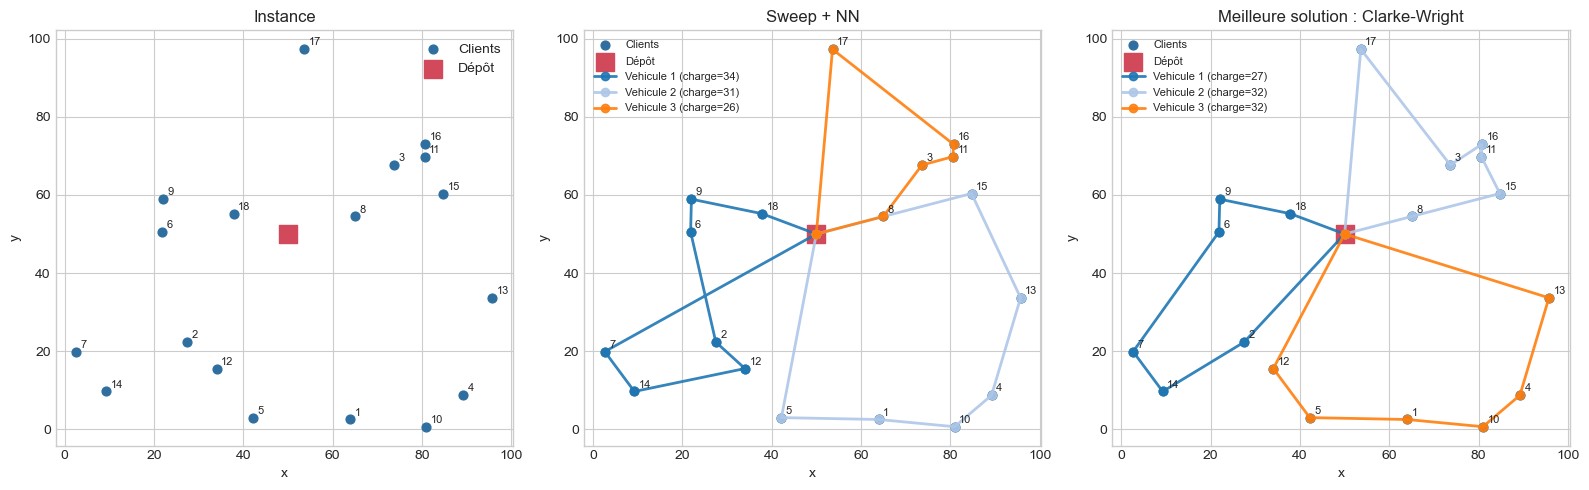


Cas B - territoire clusterisé
18 clients | distribution=clustered | demande totale=101 | capacité=38
Solveur               | Coût   | Véhicules | Temps (ms) | Écart % | Valide
----------------------+--------+-----------+------------+---------+-------
Sweep + NN            | 280.69 | 3         | 0.32       | 12.31   | True  
Sweep + NN + 2-opt    | 279.88 | 3         | 0.32       | 11.99   | True  
Clarke-Wright         | 249.91 | 3         | 0.09       | 0.00    | True  
Clarke-Wright + 2-opt | 249.91 | 3         | 0.09       | 0.00    | True  


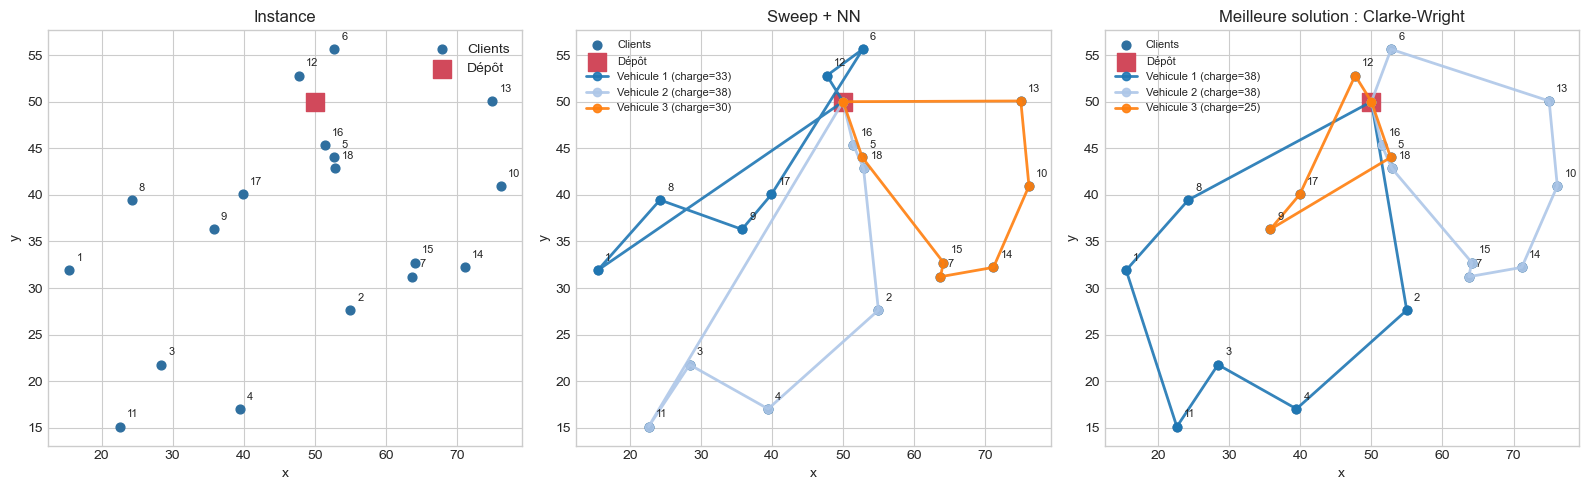

In [22]:
demo_configs = [
    {
        'label': 'Cas A - territoire uniforme',
        'num_clients': 18,
        'distribution': 'uniform',
        'capacity_tightness': 1.10,
        'seed': 42,
    },
    {
        'label': 'Cas B - territoire clusterisé',
        'num_clients': 18,
        'distribution': 'clustered',
        'capacity_tightness': 1.10,
        'seed': 99,
    },
]

for config in demo_configs:
    print('\n' + '=' * 90)
    print(config['label'])

    instance = generate_cvrp_instance(
        num_clients=config['num_clients'],
        distribution=config['distribution'],
        capacity_tightness=config['capacity_tightness'],
        seed=config['seed'],
    )

    print(describe_instance(instance))
    results = benchmark_instance(instance, SOLVERS)

    rows = [
        {
            'solver': result['solver'],
            'cost': result['cost'],
            'vehicles': result['vehicles'],
            'runtime_ms': result['runtime_ms'],
            'gap_to_best_pct': result['gap_to_best_pct'],
            'valid': result['valid'],
        }
        for result in results
    ]

    print_table(
        rows,
        columns=[
            ('solver', 'Solveur'),
            ('cost', 'Coût'),
            ('vehicles', 'Véhicules'),
            ('runtime_ms', 'Temps (ms)'),
            ('gap_to_best_pct', 'Écart %'),
            ('valid', 'Valide'),
        ],
    )

    best_result = min((result for result in results if result['valid']), key=lambda result: result['cost'])
    sweep_result = next(result for result in results if result['solver'] == 'Sweep + NN')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    plot_instance(instance, ax=axes[0], title='Instance')
    plot_solution(instance, sweep_result['routes'], ax=axes[1], title='Sweep + NN')
    plot_solution(instance, best_result['routes'], ax=axes[2], title=f"Meilleure solution : {best_result['solver']}")
    plt.tight_layout()
    plt.show()


## 8. Étude expérimentale - plan d'expérience

Nous retenons trois facteurs pour l'étude :

1. **taille de l'instance** : nombre de clients `15`, `25`, `35`, `45` ;
2. **structure spatiale** : `uniform` ou `clustered` ;
3. **tension de capacité** : `1.05` (capacité serrée) ou `1.25` (capacité plus confortable).

Chaque combinaison est répétée plusieurs fois avec des graines différentes. On obtient ainsi un plan d'expérience simple, mais suffisamment riche pour discuter :

- de la montée en charge ;
- de la robustesse des solveurs ;
- du compromis qualité / temps d'exécution ;
- de l'effet des contraintes de capacité sur le nombre de véhicules utilisés.

In [23]:
def aggregate_stats(values: Sequence[float]) -> Tuple[float, float]:
    if not values:
        return float('nan'), float('nan')
    if len(values) == 1:
        return values[0], 0.0
    return mean(values), stdev(values)


def summarize_records(records: Sequence[Dict[str, object]], group_keys: Sequence[str]) -> List[Dict[str, object]]:
    buckets: Dict[Tuple[object, ...], Dict[str, List[float]]] = {}

    for record in records:
        if not record['valid']:
            continue

        key = tuple(record[group_key] for group_key in group_keys)
        if key not in buckets:
            buckets[key] = {
                'cost': [],
                'vehicles': [],
                'runtime_ms': [],
                'gap_to_best_pct': [],
            }

        buckets[key]['cost'].append(record['cost'])
        buckets[key]['vehicles'].append(record['vehicles'])
        buckets[key]['runtime_ms'].append(record['runtime_ms'])
        buckets[key]['gap_to_best_pct'].append(record['gap_to_best_pct'])

    summary_rows: List[Dict[str, object]] = []
    for key, values in buckets.items():
        row = {group_key: key[index] for index, group_key in enumerate(group_keys)}
        row['instances'] = len(values['cost'])

        for metric_name, metric_values in values.items():
            metric_mean, metric_std = aggregate_stats(metric_values)
            row[f'{metric_name}_mean'] = metric_mean
            row[f'{metric_name}_std'] = metric_std

        summary_rows.append(row)

    return sorted(summary_rows, key=lambda row: tuple(row[group_key] for group_key in group_keys))


def run_experiment(
    client_sizes: Sequence[int] = (15, 25, 35, 45),
    distributions: Sequence[str] = ('uniform', 'clustered'),
    capacity_tightness_values: Sequence[float] = (1.05, 1.25),
    repetitions: int = 5,
    base_seed: int = 2026,
) -> List[Dict[str, object]]:
    records: List[Dict[str, object]] = []

    for n in client_sizes:
        for distribution in distributions:
            for tightness in capacity_tightness_values:
                for rep in range(repetitions):
                    seed = base_seed + 1000 * n + 100 * rep + (0 if distribution == 'uniform' else 1) + int(100 * tightness)
                    instance = generate_cvrp_instance(
                        num_clients=n,
                        distribution=distribution,
                        capacity_tightness=tightness,
                        seed=seed,
                    )

                    results = benchmark_instance(instance, SOLVERS)
                    for result in results:
                        record = {
                            'n': n,
                            'distribution': distribution,
                            'capacity_tightness': tightness,
                            'rep': rep,
                            'seed': seed,
                            'solver': result['solver'],
                            'cost': result['cost'],
                            'vehicles': result['vehicles'],
                            'runtime_ms': result['runtime_ms'],
                            'valid': result['valid'],
                            'gap_to_best_pct': result['gap_to_best_pct'],
                            'message': result['message'],
                        }
                        records.append(record)

    return records


def plot_metric_curves(
    records: Sequence[Dict[str, object]],
    metric: str,
    ylabel: str,
    tightness: float,
):
    distributions = sorted({record['distribution'] for record in records})
    solver_names = sorted({record['solver'] for record in records})

    fig, axes = plt.subplots(1, len(distributions), figsize=(7 * len(distributions), 4.5), sharey=False)
    if len(distributions) == 1:
        axes = [axes]

    for ax, distribution in zip(axes, distributions):
        subset = [
            record
            for record in records
            if record['distribution'] == distribution and abs(record['capacity_tightness'] - tightness) < 1e-12 and record['valid']
        ]
        n_values = sorted({record['n'] for record in subset})

        for solver_name in solver_names:
            y_values = []
            for n in n_values:
                values = [record[metric] for record in subset if record['solver'] == solver_name and record['n'] == n]
                y_values.append(mean(values) if values else float('nan'))
            ax.plot(n_values, y_values, marker='o', linewidth=2, label=solver_name)

        ax.set_title(f'{distribution} | capacity_tightness={tightness}')
        ax.set_xlabel('Nombre de clients')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def build_report_conclusion(records: Sequence[Dict[str, object]]) -> None:
    overall = summarize_records(records, ['solver'])
    best_quality = min(overall, key=lambda row: row['gap_to_best_pct_mean'])
    fastest = min(overall, key=lambda row: row['runtime_ms_mean'])
    lowest_cost = min(overall, key=lambda row: row['cost_mean'])

    text = (
        f"Sur le plan d'expérience exécuté ({len(records)} exécutions de solveurs), "
        f"la meilleure qualité moyenne est obtenue par {best_quality['solver']} "
        f"avec un écart moyen au meilleur de {best_quality['gap_to_best_pct_mean']:.2f} %. "
        f"La méthode la plus rapide est {fastest['solver']} "
        f"avec un temps moyen de {fastest['runtime_ms_mean']:.2f} ms. "
        f"Si l'on retient uniquement le coût total moyen, la méthode la plus performante est {lowest_cost['solver']} "
        f"avec un coût moyen de {lowest_cost['cost_mean']:.2f}."
    )
    print(text)


Nombre total de résultats enregistrés : 320

Résumé global par solveur
Solveur               | Instances | Coût moyen | Véh. moyens | Temps moyen (ms) | Écart moyen %
----------------------+-----------+------------+-------------+------------------+--------------
Clarke-Wright         | 80        | 561.83     | 5.42        | 0.22             | 0.53         
Clarke-Wright + 2-opt | 80        | 561.62     | 5.42        | 0.23             | 0.47         
Sweep + NN            | 80        | 599.75     | 5.34        | 1.04             | 7.83         
Sweep + NN + 2-opt    | 80        | 583.29     | 5.34        | 1.06             | 4.93         

Détail - instances uniformes avec capacité serrée
Clients | Solveur               | Coût moyen | Véh. moyens | Temps moyen (ms) | Écart moyen %
--------+-----------------------+------------+-------------+------------------+--------------
15      | Clarke-Wright         | 426.83     | 3.40        | 0.05             | 0.21         
15      | Clarke-Wri

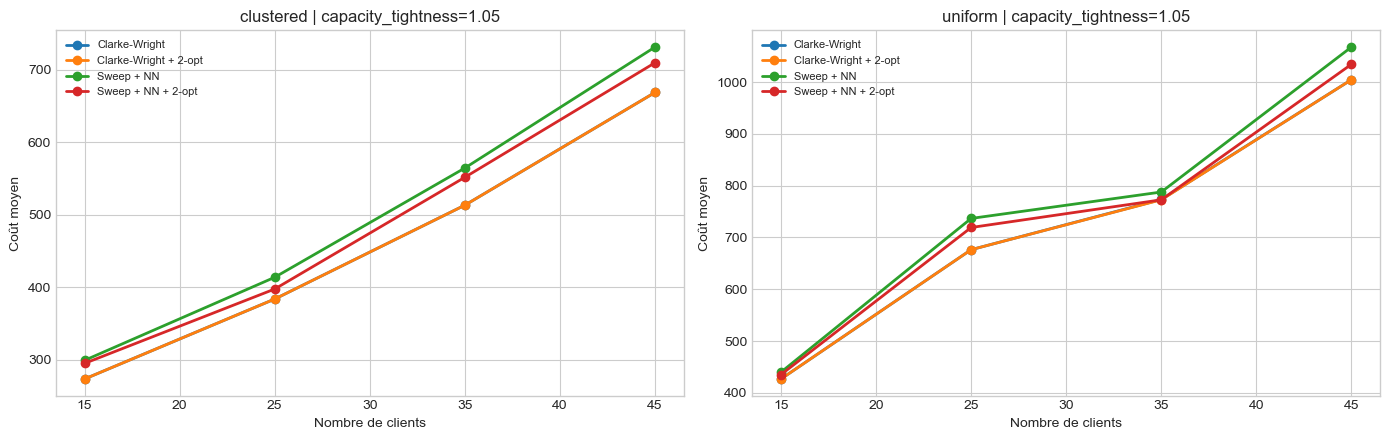

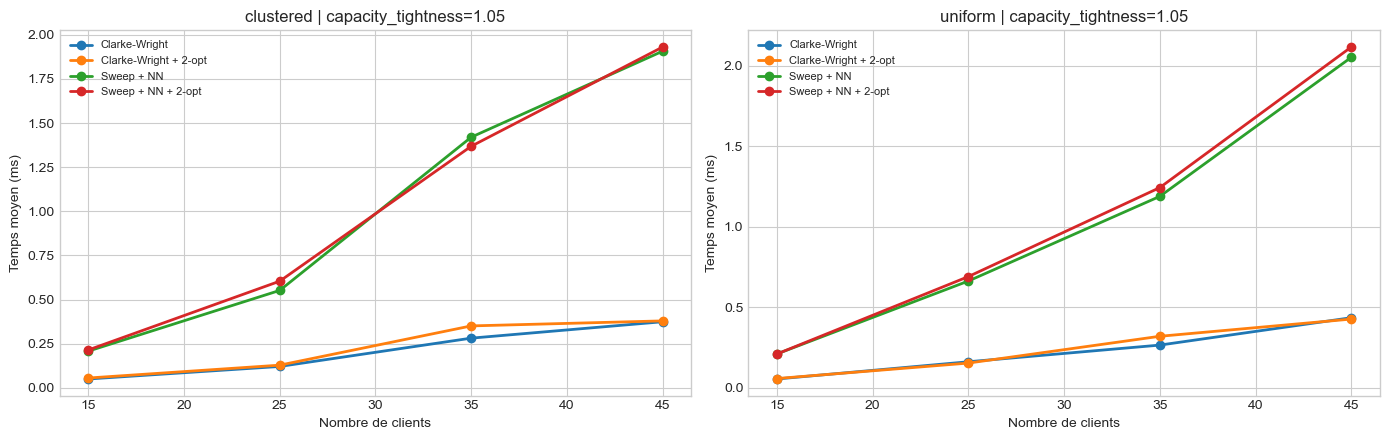

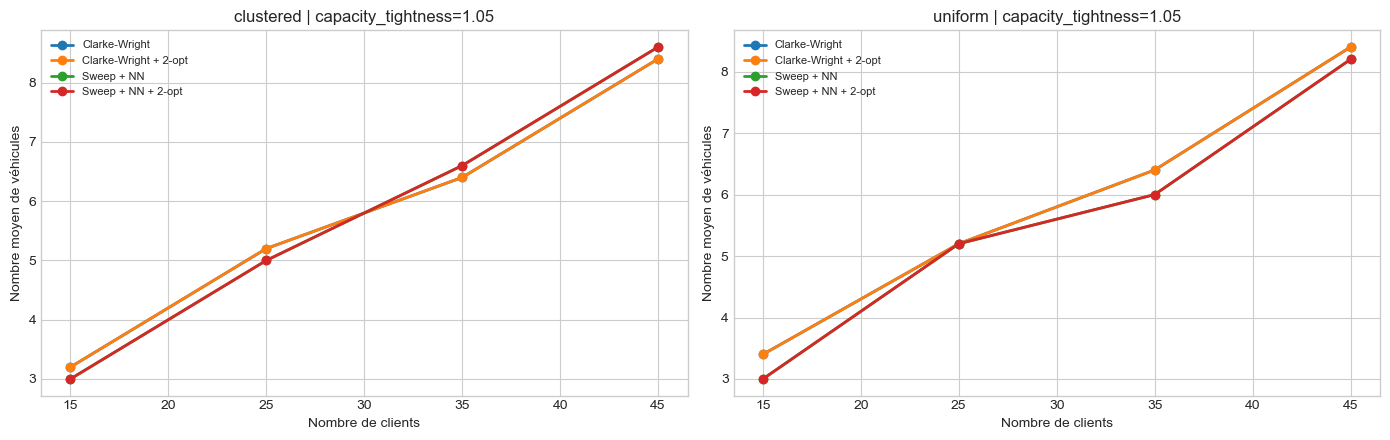


Synthèse textuelle réutilisable dans le rapport
Sur le plan d'expérience exécuté (320 exécutions de solveurs), la meilleure qualité moyenne est obtenue par Clarke-Wright + 2-opt avec un écart moyen au meilleur de 0.47 %. La méthode la plus rapide est Clarke-Wright avec un temps moyen de 0.22 ms. Si l'on retient uniquement le coût total moyen, la méthode la plus performante est Clarke-Wright + 2-opt avec un coût moyen de 561.62.


In [24]:
records = run_experiment(
    client_sizes=(15, 25, 35, 45),
    distributions=('uniform', 'clustered'),
    capacity_tightness_values=(1.05, 1.25),
    repetitions=5,
    base_seed=2026,
)

print(f'Nombre total de résultats enregistrés : {len(records)}')

overall_summary = summarize_records(records, ['solver'])
print('\nRésumé global par solveur')
print_table(
    overall_summary,
    columns=[
        ('solver', 'Solveur'),
        ('instances', 'Instances'),
        ('cost_mean', 'Coût moyen'),
        ('vehicles_mean', 'Véh. moyens'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
        ('gap_to_best_pct_mean', 'Écart moyen %'),
    ],
)

subset = [
    record
    for record in records
    if record['distribution'] == 'uniform' and abs(record['capacity_tightness'] - 1.05) < 1e-12
]
detail_summary = summarize_records(subset, ['n', 'solver'])
print('\nDétail - instances uniformes avec capacité serrée')
print_table(
    detail_summary,
    columns=[
        ('n', 'Clients'),
        ('solver', 'Solveur'),
        ('cost_mean', 'Coût moyen'),
        ('vehicles_mean', 'Véh. moyens'),
        ('runtime_ms_mean', 'Temps moyen (ms)'),
        ('gap_to_best_pct_mean', 'Écart moyen %'),
    ],
)

plot_metric_curves(records, metric='cost', ylabel='Coût moyen', tightness=1.05)
plot_metric_curves(records, metric='runtime_ms', ylabel='Temps moyen (ms)', tightness=1.05)
plot_metric_curves(records, metric='vehicles', ylabel='Nombre moyen de véhicules', tightness=1.05)

print('\nSynthèse textuelle réutilisable dans le rapport')
build_report_conclusion(records)


## 9. Lecture attendue des résultats

Après exécution des cellules précédentes, l'analyse doit répondre aux questions suivantes :

- quel solveur donne le **meilleur coût moyen** ;
- quel solveur est le **plus rapide** ;
- comment évoluent coût et temps d'exécution quand le nombre de clients augmente ;
- quel est l'effet d'une capacité plus serrée sur le **nombre de véhicules** ;
- dans quelles situations le **2-opt** apporte un gain intéressant.

En général, on s'attend à observer le comportement suivant :

- **Sweep + NN** est très rapide mais plus sensible à la géométrie des instances ;
- **Clarke-Wright** produit souvent de meilleurs regroupements de clients ;
- l'ajout de **2-opt** améliore surtout la qualité des tournées lorsque des détours ou croisements subsistent ;
- lorsque `capacity_tightness` est faible, le nombre de tournées augmente mécaniquement.

Les tableaux et graphiques ci-dessus permettent de justifier ces observations sur des résultats statistiques, et non sur un unique exemple.

## 10. Limites et perspectives d'amélioration

### Limites de la version actuelle

- le graphe est complet et euclidien, ce qui simplifie fortement le réseau routier réel ;
- il n'y a pas encore de fenêtres temporelles, ni d'arêtes interdites, ni de trafic dynamique ;
- les solveurs restent heuristiques et ne garantissent pas l'optimalité.

### Pistes d'amélioration crédibles

- intégrer un solveur exact pour de petites instances afin d'obtenir une borne de référence ;
- ajouter de nouvelles contraintes métier : **fenêtres temporelles**, **routes interdites**, **dépendances entre visites** ;
- remplacer la distance euclidienne par un coût issu d'un vrai réseau routier ;
- tester des métaheuristiques plus puissantes : **tabou**, **recuit simulé**, **algorithmes génétiques** ;
- passer à une approche multi-objectif en ajoutant explicitement les émissions de CO2.

Ces extensions prolongent naturellement ce notebook vers un démonstrateur ADEME plus réaliste.

## 11. Conclusion

Ce notebook constitue désormais une base cohérente pour le livrable final :

- la **modélisation** est formalisée ;
- les **méthodes de résolution** sont décrites et implémentées ;
- une **démonstration** est fournie sur différents cas de test ;
- un **plan d'expérience** complet permet de mesurer les performances, les limites et les perspectives d'amélioration.

Il peut être utilisé tel quel comme support technique du rapport, puis enrichi avec les captures de résultats obtenus après exécution dans Jupyter.